In [ ]:
import os
import shutil
import random
from pathlib import Path

In [ ]:
#data splitting:

original_dataset_path = Path("/content/drive/MyDrive/dataset-resized")
output_dataset_path = Path("/content/trashnet_yolo")

train_split = 0.7
val_split = 0.15
test_split = 0.15

assert abs(train_split + val_split + test_split - 1.0) < 1e-6, "Splits must sum to 1"

for split in ["train", "val", "test"]:
    for class_name in os.listdir(original_dataset_path):
        (output_dataset_path / split / class_name).mkdir(parents=True, exist_ok=True)

for class_name in os.listdir(original_dataset_path):
    class_dir = original_dataset_path / class_name
    images = os.listdir(class_dir)
    random.shuffle(images)

    train_count = int(len(images) * train_split)
    val_count = int(len(images) * val_split)

    train_files = images[:train_count]
    val_files = images[train_count:train_count + val_count]
    test_files = images[train_count + val_count:]

    for img in train_files:
        shutil.copy(class_dir / img, output_dataset_path / "train" / class_name)
    for img in val_files:
        shutil.copy(class_dir / img, output_dataset_path / "val" / class_name)
    for img in test_files:
        shutil.copy(class_dir / img, output_dataset_path / "test" / class_name)

print("✅ Data split complete! YOLOv11-ready folder structure created.")

✅ Data split complete! YOLOv11-ready folder structure created.


In [ ]:
#installing yolov11:

!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00


In [ ]:
#training phase:
from ultralytics import YOLO

# Download the correct yolov11n-cls.pt file
!wget https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov11n-cls.pt

model = YOLO("yolo11n-cls.pt")

results = model.train(
    data=str(output_dataset_path),
    epochs=50,
    imgsz=224,
    batch=32
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--2025-08-28 00:13:47--  https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov11n-cls.pt
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-08-28 00:13:48 ERROR 404: Not Found.

Ultralytics 8.3.187 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trashnet_yolo, deg

In [ ]:
from google.colab import files
files.download("/content/runs/classify/train/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import pandas as pd

In [ ]:
log_path = results.save_dir / 'results.csv'
df = pd.read_csv(log_path)

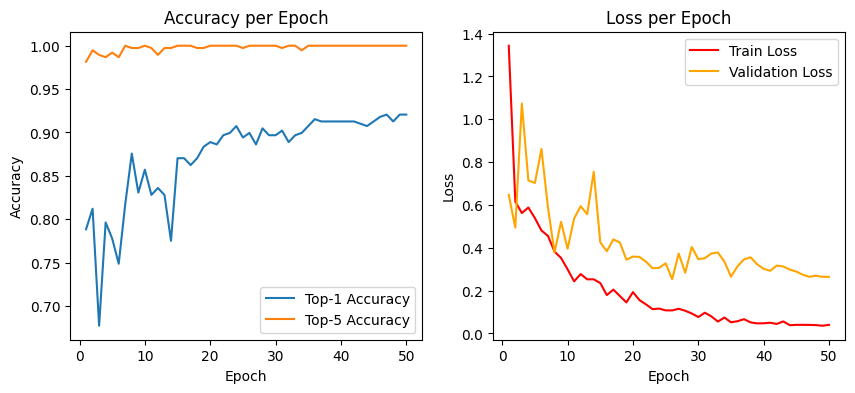

In [ ]:
#plotting the results

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Top-1 Accuracy")
plt.plot(df["epoch"], df["metrics/accuracy_top5"], label="Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy per Epoch")

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df["train/loss"], label="Train Loss", color='red')
plt.plot(df["epoch"], df["val/loss"], label="Validation Loss", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()



0: 224x224 metal 1.00, glass 0.00, paper 0.00, cardboard 0.00, plastic 0.00, 0.3ms
1: 224x224 glass 0.87, metal 0.12, paper 0.01, plastic 0.01, cardboard 0.00, 0.3ms
2: 224x224 metal 1.00, trash 0.00, plastic 0.00, glass 0.00, paper 0.00, 0.3ms
3: 224x224 metal 1.00, glass 0.00, paper 0.00, cardboard 0.00, plastic 0.00, 0.3ms
4: 224x224 metal 1.00, cardboard 0.00, glass 0.00, trash 0.00, paper 0.00, 0.3ms
5: 224x224 metal 1.00, trash 0.00, paper 0.00, cardboard 0.00, glass 0.00, 0.3ms
6: 224x224 metal 0.99, glass 0.01, paper 0.00, cardboard 0.00, plastic 0.00, 0.3ms
7: 224x224 metal 1.00, plastic 0.00, trash 0.00, paper 0.00, glass 0.00, 0.3ms
8: 224x224 metal 0.97, paper 0.02, trash 0.00, cardboard 0.00, glass 0.00, 0.3ms
9: 224x224 metal 1.00, plastic 0.00, cardboard 0.00, paper 0.00, glass 0.00, 0.3ms
10: 224x224 metal 1.00, glass 0.00, trash 0.00, cardboard 0.00, plastic 0.00, 0.3ms
11: 224x224 metal 1.00, glass 0.00, paper 0.00, plastic 0.00, cardboard 0.00, 0.3ms
12: 224x224 met

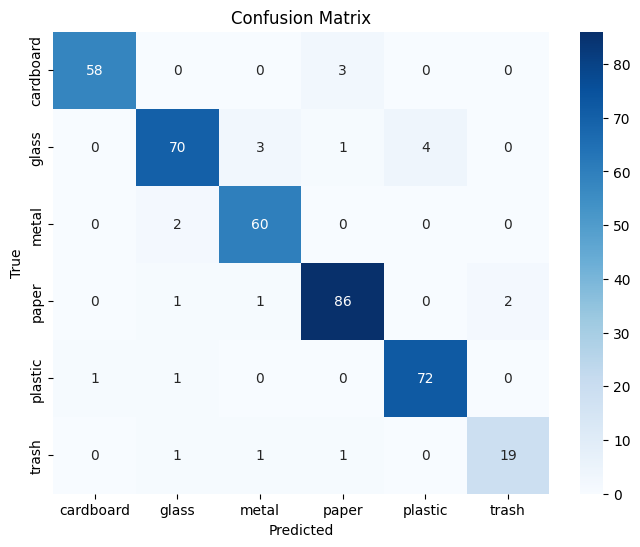


Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.95      0.97        61
       glass       0.93      0.90      0.92        78
       metal       0.92      0.97      0.94        62
       paper       0.95      0.96      0.95        90
     plastic       0.95      0.97      0.96        74
       trash       0.90      0.86      0.88        22

    accuracy                           0.94       387
   macro avg       0.94      0.93      0.94       387
weighted avg       0.94      0.94      0.94       387



In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import glob
import os

# Load your trained model
model = YOLO("/content/runs/classify/train/weights/best.pt")

# Get predictions on the test set
test_dataset_path = "/content/trashnet_yolo/test"

# Get a list of all image files in the test directory and its subdirectories
image_files = glob.glob(os.path.join(test_dataset_path, '**', '*.jpg'), recursive=True)
image_files.extend(glob.glob(os.path.join(test_dataset_path, '**', '*.png'), recursive=True))
# Add other supported formats if necessary

if not image_files:
    print(f"Error: No image files found in {test_dataset_path} or its subdirectories.")
else:
    results_predict = model.predict(image_files)

    # Extract predicted and true labels
    preds = []
    labels = []
    # Assuming class_names can be obtained from the model or a known list
    # If not available, you might need to get it from the training results or define it manually
    # For now, let's try to get it from the first prediction result if available
    class_names = results_predict[0].names if results_predict and hasattr(results_predict[0], 'names') else None

    if class_names is None:
        print("Could not determine class names. Cannot generate confusion matrix or classification report.")
    else:
        for result in results_predict:
            # For classification, the prediction is the class index with the highest probability
            preds.append(result.probs.top1)
            # The true label needs to be determined from the directory structure
            image_path = result.path
            # Extract class name from the path, assuming /test/class_name/image.jpg structure
            class_name_true = image_path.split('/')[-2]
            # Find the corresponding class index
            try:
                true_label_index = list(class_names.keys())[list(class_names.values()).index(class_name_true)]
                labels.append(true_label_index)
            except ValueError:
                 print(f"Warning: Could not find class name '{class_name_true}' in class_names.")
                 # Optionally, skip this image or handle the missing class

        # Convert to numpy arrays
        preds = np.array(preds)
        labels = np.array(labels)

        # Confusion matrix
        cm = confusion_matrix(labels, preds)

        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names.values(),
                    yticklabels=class_names.values())
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix")
        plt.show()

        # Classification report
        print("\nClassification Report:")
        print(classification_report(labels, preds, target_names=class_names.values()))

In [ ]:
# Print final accuracy and loss
final_row = df.iloc[-1]

print(f"Final Top-1 Accuracy: {final_row['metrics/accuracy_top1']:.4f}")
print(f"Final Top-5 Accuracy: {final_row['metrics/accuracy_top5']:.4f}")
print(f"Final Train Loss: {final_row['train/loss']:.4f}")
print(f"Final Validation Loss: {final_row['val/loss']:.4f}")

Final Top-1 Accuracy: 0.9206
Final Top-5 Accuracy: 1.0000
Final Train Loss: 0.0398
Final Validation Loss: 0.2641


In [ ]:
import os

# List files in the directory where best.pt is expected
expected_dir = "/content/runs/classify/train/"

if os.path.exists(expected_dir):
    print(f"Contents of {expected_dir}:")
    for item in os.listdir(expected_dir):
        print(item)
else:
    print(f"Directory not found: {expected_dir}")

Directory not found: /content/runs/classify/train/
